Tested with following versions:

*   python 3.11.13
*   numpy 2.2.2
*   pandas 2.0.2
*   sklearn 1.6.1


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold


In [2]:
# Download the data
!wget -O WAHousePrice.xlsx https://www.dropbox.com/scl/fi/7py0wnil5obkr16bwuwfw/WAHousePrice.xlsx?rlkey=s8riinvpub4n1dfg9cv9ypzhh&dl=0

# Import
data = pd.read_excel("WAHousePrice.xlsx")
print(data.head())

--2026-01-26 16:41:34--  https://www.dropbox.com/scl/fi/7py0wnil5obkr16bwuwfw/WAHousePrice.xlsx?rlkey=s8riinvpub4n1dfg9cv9ypzhh
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc845d0db1ae92f8daa6be34ca47.dl.dropboxusercontent.com/cd/0/inline/C5tyKulv26go35goFvMIcTEPcHe5xm1jJu2McQhgwTXd7zRA8OfmE28WZdE3NbLwPYP_hpm30LGwPeME_3U4RttwcKO32PlCzSOagOxbHzhVlqj3YZPOEKy5YRP7ob_PBlWdrRquPuRiSVN2n-Y5N1o3/file# [following]
--2026-01-26 16:41:35--  https://uc845d0db1ae92f8daa6be34ca47.dl.dropboxusercontent.com/cd/0/inline/C5tyKulv26go35goFvMIcTEPcHe5xm1jJu2McQhgwTXd7zRA8OfmE28WZdE3NbLwPYP_hpm30LGwPeME_3U4RttwcKO32PlCzSOagOxbHzhVlqj3YZPOEKy5YRP7ob_PBlWdrRquPuRiSVN2n-Y5N1o3/file
Resolving uc845d0db1ae92f8daa6be34ca47.dl.dropboxusercontent.com (uc845d0db1ae92f8daa6be34ca47.dl.dropboxusercontent.com)... 162.125.6.15

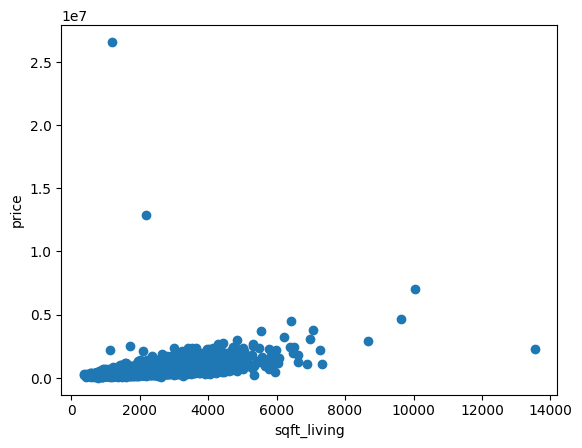

In [3]:
# Plot price vs sqrt_living
plt.scatter(data["sqft_living"], data["price"])
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.show()


In [4]:
# Descriptive statistics
data.describe()

,date,price,bathrooms,bedrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4551,4.551000e+03,4551.000000,4551.000000,4551.000000,4.551000e+03,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000
mean,2014-06-07 03:59:12.537903872,5.579059e+05,2.155021,3.394639,2132.372226,1.483528e+04,1.512195,0.006592,0.234674,3.449352,1822.221710,310.150516,1970.795649,808.564052
min,2014-05-02 00:00:00,7.800000e+03,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,2014-05-21 00:00:00,3.262643e+05,1.750000,3.000000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,2014-06-09 00:00:00,4.650000e+05,2.250000,3.000000,1970.000000,7.680000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,2014-06-24 00:00:00,6.575000e+05,2.500000,4.000000,2610.000000,1.097800e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,600.000000,1997.000000,1999.000000
max,2014-07-10 00:00:00,2.659000e+07,8.000000,9.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000
std,NaN,5.639299e+05,0.776351,0.904595,955.949708,3.596408e+04,0.538531,0.080932,0.765373,0.675160,854.452888,461.987629,29.760073,979.421487


In [5]:
# Let's find the observations with 0 bedrooms or 0 bathrooms and see what they look like
data[(data['bedrooms'] == 0) | (data['bathrooms'] == 0)]

,date,price,bathrooms,bedrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
1750,2014-06-12,1095000.0,0.0,0,3064,4764,3.5,0,2,3,3064,0,1990,2009,814 E Howe St,Seattle,WA 98102,USA
2394,2014-06-24,1295648.0,0.0,0,4810,28008,2.0,0,0,3,4810,0,1990,2009,20418 NE 64th Pl,Redmond,WA 98053,USA


In [6]:
# Drop the flagged observations
data = data[(data['bedrooms'] != 0) & (data['bathrooms'] != 0)]

In [7]:
# Let's find the observations with very low prices and see what they look like
data[data['price'] < 50000]

,date,price,bathrooms,bedrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
3215,2014-05-06,7800.0,1.0,2,780,16344,1.0,0,0,1,780,0,1942,0,4229 S 144th St,Tukwila,WA 98168,USA


In [8]:
# Let's find the observations with very high prices and see what they look like
data[data['price'] > 5000000]

,date,price,bathrooms,bedrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
1693,2014-06-11,7062500.0,4.5,5,10040,37325,2.0,1,2,3,7680,2360,1940,2001,4442 95th Ave NE,Bellevue,WA 98004,USA
3211,2014-06-23,12899000.0,2.5,3,2190,11394,1.0,0,0,3,1550,640,1956,2001,5426 40th Ave W,Seattle,WA 98199,USA
3214,2014-07-03,26590000.0,2.0,3,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,USA


In [9]:
# Drop observations that seem "fishy"
data = data[data['price'] >= 50000]
data = data[data['price'] <= 10000000]

In [10]:
# Drop variables we definitely won't use
data = data.drop(columns=['date','street','country'])

In [11]:
# Split the data into training and validation sets
train_data, validation_data = train_test_split(data, test_size=1000, random_state=726)

In [12]:
# Baseline descriptive statistics for price and sqft_living in the training data
train_data[['price', 'sqft_living']].describe()

,price,sqft_living
count,3.546000e+03,3546.000000
mean,5.499274e+05,2138.270164
std,3.678035e+05,958.403354
min,8.000000e+04,370.000000
25%,3.261821e+05,1470.000000
50%,4.650000e+05,1970.000000
75%,6.575000e+05,2630.000000
max,7.062500e+06,13540.000000


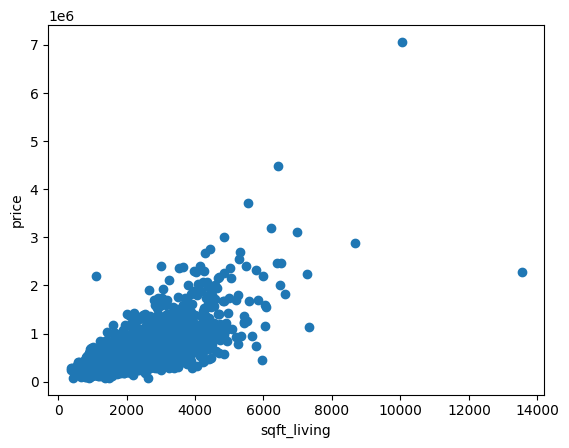

In [13]:
# Let's plot price vs square footage in the training data
plt.scatter(train_data["sqft_living"], train_data["price"])
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.show()

In [14]:
# Create a variable which is square footage plus noise
np.random.seed(42)
train_data['sqft_noise'] = train_data['sqft_living'] + np.random.normal(0, 10, len(train_data))
validation_data['sqft_noise'] = validation_data['sqft_living'] + np.random.normal(0, 10, len(validation_data))

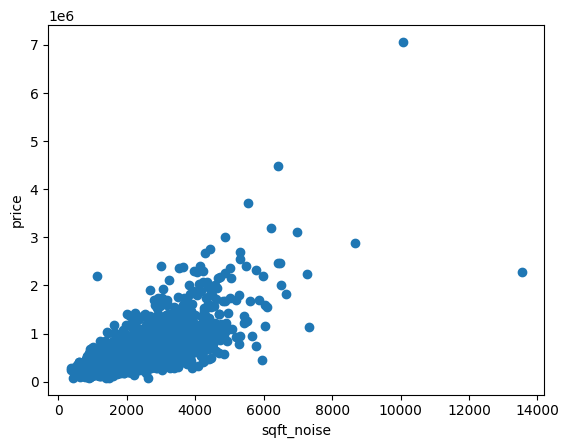

In [15]:
# Let's plot price vs noisy square footage in the training data
plt.scatter(train_data["sqft_noise"], train_data["price"])
plt.xlabel("sqft_noise")
plt.ylabel("price")
plt.show()

Sample mean of price: 549927.35
MSE of sample mean: 135241240351.23
RMSE of sample mean: 367751.60
MAE of sample mean: 236398.06


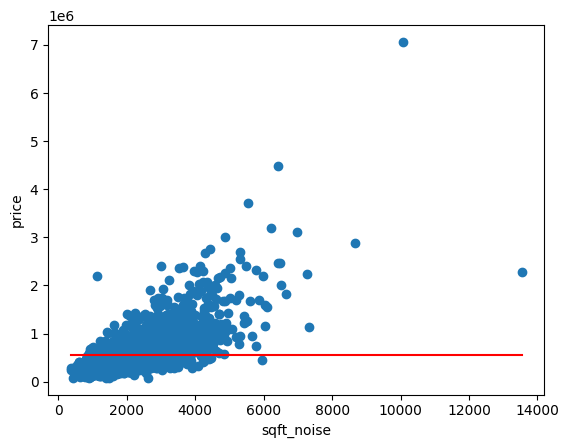

In [16]:
# Sample mean as prediction rule
ytrmean = np.mean(train_data['price'])
print('Sample mean of price: {m:=.2f}'.format(m=ytrmean))

# Mean squared error
mse_mean = np.mean((train_data['price'] - ytrmean)**2)
print('MSE of sample mean: {m:=.2f}'.format(m=mse_mean))

# Root mean squared error
rmse_mean = np.sqrt(mse_mean)
print('RMSE of sample mean: {m:=.2f}'.format(m=rmse_mean))

# Mean absolute error
mae_mean = np.mean(np.abs(train_data['price'] - ytrmean))
print('MAE of sample mean: {m:=.2f}'.format(m=mae_mean))

# R^2
r2_mean = 0

# Scatter plot with mean line drawn on
plt.scatter(train_data['sqft_noise'], train_data['price'])
plt.plot([min(train_data['sqft_noise']), max(train_data['sqft_noise'])], [ytrmean, ytrmean], color='red')
plt.xlabel("sqft_noise")
plt.ylabel("price")
plt.show()

MSE of linear model: 68360185215.53
RMSE of linear model: 261457.81
MAE of linear model: 173035.08
Linear model R^2 in training data: 0.494532


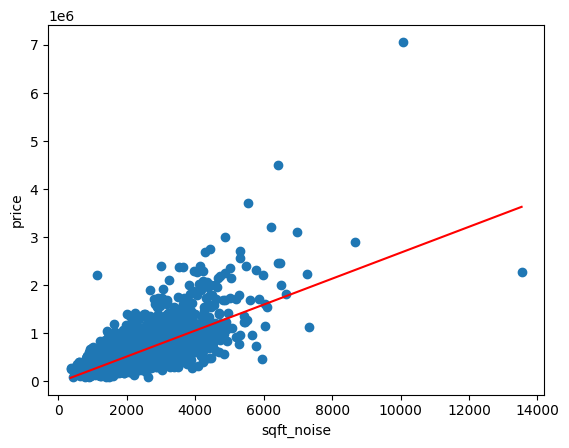

In [17]:
# Linear model
model_lm = LinearRegression()
model_lm.fit(train_data[['sqft_noise']], train_data['price'])

# Fitted values
train_data['lm_price_fitted'] = model_lm.predict(train_data[['sqft_noise']])

# MSE
mse_lm = np.mean((train_data['price'] - train_data['lm_price_fitted'])**2)
print('MSE of linear model: {m:=.2f}'.format(m=mse_lm))

# RMSE
rmse_lm = np.sqrt(mse_lm)
print('RMSE of linear model: {m:=.2f}'.format(m=rmse_lm))

# MAE
mae_lm = np.mean(np.abs(train_data['price'] - train_data['lm_price_fitted']))
print('MAE of linear model: {m:=.2f}'.format(m=mae_lm))

#R^2
r2_lm= model_lm.score(train_data[['sqft_noise']], train_data['price'])
print("Linear model R^2 in training data: %f" % r2_lm)

# Scatter plot with linear model line drawn on
sorted_data = train_data.sort_values(by='sqft_noise')
plt.scatter(train_data['sqft_noise'], train_data['price'])
plt.plot(sorted_data['sqft_noise'], sorted_data['lm_price_fitted'], color='red')
plt.xlabel("sqft_noise")
plt.ylabel("price")
plt.show()


MSE of tree model with 4 leaves: 72467737010.21
RMSE of tree model with 4 leaves: 269198.32
MAE of tree model with 4 leaves: 177424.64
Tree model with 4 leaves R^2 in training data: 0.464159


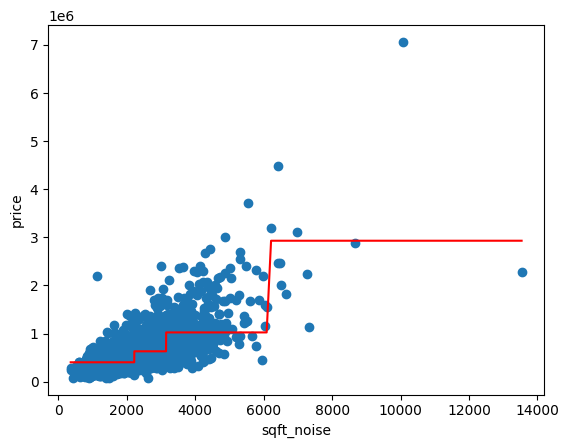

In [18]:
# Fit a tree model in the training data with four leaves
model_t4 = DecisionTreeRegressor(max_leaf_nodes=4)
model_t4.fit(train_data[['sqft_noise']], train_data['price'])

# Fitted values
train_data['tree_price_fitted'] = model_t4.predict(train_data[['sqft_noise']])

# Mean squared error
mse_tree = np.mean((train_data['price'] - train_data['tree_price_fitted'])**2)
print('MSE of tree model with 4 leaves: {m:=.2f}'.format(m=mse_tree))

# RMSE
rmse_tree = np.sqrt(mse_tree)
print('RMSE of tree model with 4 leaves: {m:=.2f}'.format(m=rmse_tree))

# MAE
mae_tree = np.mean(np.abs(train_data['price'] - train_data['tree_price_fitted']))
print('MAE of tree model with 4 leaves: {m:=.2f}'.format(m=mae_tree))

# R^2
r2_tree = model_t4.score(train_data[['sqft_noise']], train_data['price'])
print("Tree model with 4 leaves R^2 in training data: %f" % r2_tree)

# Scatter plot with tree fit drawn on
sorted_data = train_data.sort_values(by='sqft_noise')
plt.scatter(train_data['sqft_noise'], train_data['price'])
plt.plot(sorted_data['sqft_noise'], sorted_data['tree_price_fitted'], color='red')
plt.xlabel("sqft_noise")
plt.ylabel("price")
plt.show()


MSE of KNN model with 50 neighbors: 67102332574.81
RMSE of KNN model with 50 neighbors: 259041.18
MAE of KNN model with 50 neighbors: 165684.64
KNN model with 50 neighbors R^2 in training data: 0.503832


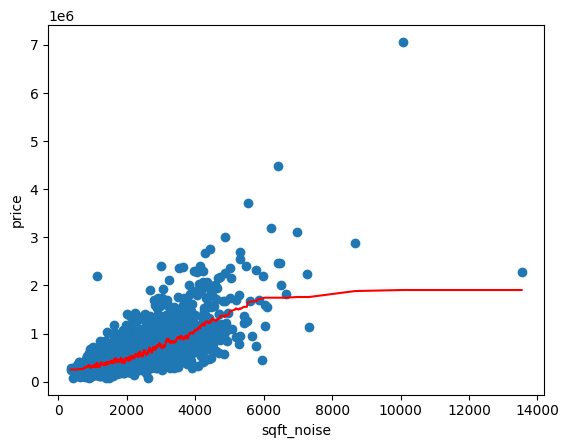

In [19]:
# Fit a KNN model with 50 neighbors
model_knn = KNeighborsRegressor(n_neighbors=50)
model_knn.fit(train_data[['sqft_noise']], train_data['price'])

# Fitted values
train_data['knn_price_fitted'] = model_knn.predict(train_data[['sqft_noise']])

# Mean squared error
mse_knn = np.mean((train_data['price'] - train_data['knn_price_fitted'])**2)
print('MSE of KNN model with 50 neighbors: {m:=.2f}'.format(m=mse_knn))

# RMSE
rmse_knn = np.sqrt(mse_knn)
print('RMSE of KNN model with 50 neighbors: {m:=.2f}'.format(m=rmse_knn))

# MAE
mae_knn = np.mean(np.abs(train_data['price'] - train_data['knn_price_fitted']))
print('MAE of KNN model with 50 neighbors: {m:=.2f}'.format(m=mae_knn))

# R^2
r2_knn = model_knn.score(train_data[['sqft_noise']], train_data['price'])
print("KNN model with 50 neighbors R^2 in training data: %f" % r2_knn)

# Plot estimated model vs original data
sorted_data = train_data.sort_values(by='sqft_noise')
plt.scatter(train_data['sqft_noise'], train_data['price'])
plt.plot(sorted_data['sqft_noise'], sorted_data['knn_price_fitted'], color='red')
plt.xlabel("sqft_noise")
plt.ylabel("price")
plt.show()


MSE of BIG tree model: 0.00
RMSE of BIG tree model: 0.00
MAE of BIG tree model: 0.00
R^2 performance of the model in training data: 1.000000


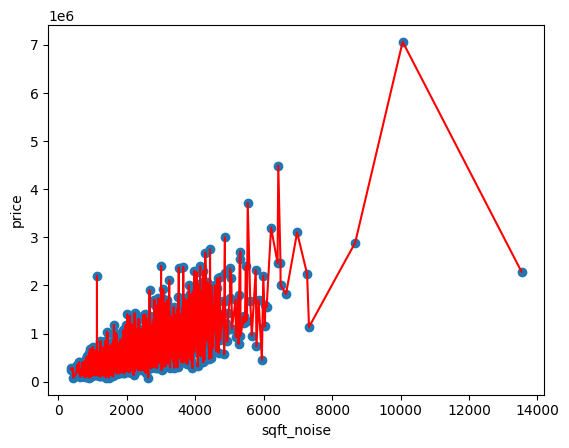

In [20]:
# Fit a tree model in the training data with one observation per leaf
model = DecisionTreeRegressor(min_samples_leaf=1)
model.fit(train_data[['sqft_noise']], train_data['price'])

# Fitted values
train_data['perfect_price_fitted'] = model.predict(train_data[['sqft_noise']])

# Mean squared error
mse_perfect = np.mean((train_data['price'] - train_data['perfect_price_fitted'])**2)
print('MSE of BIG tree model: {m:=.2f}'.format(m=mse_perfect))

# RMSE
rmse_perfect = np.sqrt(mse_perfect)
print('RMSE of BIG tree model: {m:=.2f}'.format(m=rmse_perfect))

# MAE
mae_perfect = np.mean(np.abs(train_data['price'] - train_data['perfect_price_fitted']))
print('MAE of BIG tree model: {m:=.2f}'.format(m=mae_perfect))

# Calculate in-sample R^2
r2_perfect = model.score(train_data[['sqft_noise']], train_data['price'])
print("R^2 performance of the model in training data: %f" % r2_perfect)

# Plot estimated tree model vs original data
sorted_data = train_data.sort_values(by='sqft_noise')
plt.scatter(train_data['sqft_noise'], train_data['price'])
plt.plot(sorted_data['sqft_noise'], sorted_data['perfect_price_fitted'], color='red')
plt.xlabel("sqft_noise")
plt.ylabel("price")
plt.show()



In [21]:
# Model performance in the validation data

# First form predictions for each model in the validation data
validation_data['mean_predict'] = ytrmean
validation_data['lm_predict'] = model_lm.predict(validation_data[['sqft_noise']])
validation_data['tree_predict'] = model_t4.predict(validation_data[['sqft_noise']])
validation_data['knn_predict'] = model_knn.predict(validation_data[['sqft_noise']])
validation_data['perfect_predict'] = model.predict(validation_data[['sqft_noise']])

# MSEs
val_mse_mean = np.mean((validation_data['price'] - validation_data['mean_predict'])**2)
val_mse_lm = np.mean((validation_data['price'] - validation_data['lm_predict'])**2)
val_mse_tree = np.mean((validation_data['price'] - validation_data['tree_predict'])**2)
val_mse_knn = np.mean((validation_data['price'] - validation_data['knn_predict'])**2)
val_mse_perfect = np.mean((validation_data['price'] - validation_data['perfect_predict'])**2)

# RMSEs
val_rmse_mean = np.sqrt(val_mse_mean)
val_rmse_lm = np.sqrt(val_mse_lm)
val_rmse_tree = np.sqrt(val_mse_tree)
val_rmse_knn = np.sqrt(val_mse_knn)
val_rmse_perfect = np.sqrt(val_mse_perfect)

# MAEs
val_mae_mean = np.mean(np.abs(validation_data['price'] - validation_data['mean_predict']))
val_mae_lm = np.mean(np.abs(validation_data['price'] - validation_data['lm_predict']))
val_mae_tree = np.mean(np.abs(validation_data['price'] - validation_data['tree_predict']))
val_mae_knn = np.mean(np.abs(validation_data['price'] - validation_data['knn_predict']))
val_mae_perfect = np.mean(np.abs(validation_data['price'] - validation_data['perfect_predict']))

# OOS R^2
val_r2_mean = 1 - val_mse_mean/val_mse_mean
val_r2_lm = 1 - val_mse_lm/val_mse_mean
val_r2_tree = 1 - val_mse_tree/val_mse_mean
val_r2_knn = 1 - val_mse_knn/val_mse_mean
val_r2_perfect = 1 - val_mse_perfect/val_mse_mean

# Data frame comparing in-sample to out-of-sample fit measures
df_compare = pd.DataFrame({
    'Model': ['Mean', 'Linear', 'Tree4', 'KNN50', 'Perfect'],
    'In MSE': [mse_mean, mse_lm, mse_tree, mse_knn, mse_perfect],
    'In RMSE': [rmse_mean, rmse_lm, rmse_tree, rmse_knn, rmse_perfect],
    'In MAE': [mae_mean, mae_lm, mae_tree, mae_knn, mae_perfect],
    'In R^2': [r2_mean, r2_lm, r2_tree, r2_knn, r2_perfect],
    'Out MSE': [val_mse_mean, val_mse_lm, val_mse_tree, val_mse_knn, val_mse_perfect],
    'Out RMSE': [val_rmse_mean, val_rmse_lm, val_rmse_tree, val_rmse_knn, val_rmse_perfect],
    'Out MAE': [val_mae_mean, val_mae_lm, val_mae_tree, val_mae_knn, val_mae_perfect],
    'Out R^2': [val_r2_mean, val_r2_lm, val_r2_tree, val_r2_knn, val_r2_perfect]
})

# Print data frame
print(df_compare)




     Model        In MSE        In RMSE         In MAE    In R^2  \
0     Mean  1.352412e+11  367751.601426  236398.061349  0.000000   
1   Linear  6.836019e+10  261457.807716  173035.080122  0.494532   
2    Tree4  7.246774e+10  269198.322822  177424.636839  0.464159   
3    KNN50  6.710233e+10  259041.179303  165684.641980  0.503832   
4  Perfect  0.000000e+00       0.000000       0.000000  1.000000   

        Out MSE       Out RMSE        Out MAE   Out R^2  
0  1.359691e+11  368739.847459  237996.391869  0.000000  
1  7.420408e+10  272404.259297  177069.235269  0.454258  
2  8.097305e+10  284557.643416  183263.350903  0.404474  
3  7.733847e+10  278097.942892  173133.972505  0.431205  
4  1.214268e+11  348463.415444  233181.156785  0.106953  


In [22]:
# Let's repeat the exercise using 5 fold cross-validation in the training data
# and compare cross-validation to what we get in the validation data
# First, let's create a function that will perform 5 fold cross-validation
# and return the mean of the cross-validation results

class MeanRegressor:
    def fit(self, X, y):
        self.mean_ = np.mean(y)
    def predict(self, X):
        return np.full(shape=(len(X),), fill_value=self.mean_)
    def score(self, X, y):
        # R^2 for mean model is always 0
        return 0

model_mean = MeanRegressor()

def cross_validate(model, data, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=726)
    mse_scores = []
    rmse_scores = []
    mae_scores = []
    r2_scores = []
    for train_index, val_index in kf.split(data):
        tr_data = data.iloc[train_index]
        val_data = data.iloc[val_index].copy()
        model.fit(tr_data[['sqft_noise']], tr_data['price'])
        val_data['predict'] = model.predict(val_data[['sqft_noise']])
        mse_scores.append(np.mean((val_data['price'] - val_data['predict'])**2))
        rmse_scores.append(np.sqrt(np.mean((val_data['price'] - val_data['predict'])**2)))
        mae_scores.append(np.mean(np.abs(val_data['price'] - val_data['predict'])))
        r2_scores.append(1-np.mean((val_data['price'] - val_data['predict'])**2)
            /np.mean((val_data['price'] - np.mean(tr_data['price']))**2))
    return mse_scores, rmse_scores, mae_scores, r2_scores


In [23]:
mse_mean_cv, rmse_mean_cv, mae_mean_cv, r2_mean_cv = cross_validate(model_mean, train_data)
print('MeanRegressor fold scores:')
print('MSE:', [f'{score:.2f}' for score in mse_mean_cv])
print('RMSE:', [f'{score:.2f}' for score in rmse_mean_cv])
print('MAE:', [f'{score:.2f}' for score in mae_mean_cv])
print('R2:', [f'{score:.4f}' for score in r2_mean_cv])

MeanRegressor fold scores:
MSE: ['177638197562.63', '111136783833.53', '120438479189.63', '132315173940.30', '134893874998.60']
RMSE: ['421471.47', '333371.84', '347042.47', '363751.53', '367279.02']
MAE: ['243976.51', '232028.77', '231134.35', '235847.68', '239232.20']
R2: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000']


In [24]:
mse_lm_cv, rmse_lm_cv, mae_lm_cv, r2_lm_cv = cross_validate(model_lm, train_data)
print('LinearRegression fold scores:')
print('MSE:', [f'{score:.2f}' for score in mse_lm_cv])
print('RMSE:', [f'{score:.2f}' for score in rmse_lm_cv])
print('MAE:', [f'{score:.2f}' for score in mae_lm_cv])
print('R2:', [f'{score:.4f}' for score in r2_lm_cv])

LinearRegression fold scores:
MSE: ['90467994588.60', '53029791332.22', '58497459090.03', '65077692576.83', '76139926266.38']
RMSE: ['300778.98', '230281.98', '241862.48', '255103.30', '275934.64']
MAE: ['176618.58', '167584.71', '166661.59', '173786.27', '180882.85']
R2: ['0.4907', '0.5228', '0.5143', '0.5082', '0.4356']


In [25]:
mse_tree_cv, rmse_tree_cv, mae_tree_cv, r2_tree_cv = cross_validate(model_t4, train_data)
print('Tree4 fold scores:')
print('MSE:', [f'{score:.2f}' for score in mse_tree_cv])
print('RMSE:', [f'{score:.2f}' for score in rmse_tree_cv])
print('MAE:', [f'{score:.2f}' for score in mae_tree_cv])
print('R2:', [f'{score:.4f}' for score in r2_tree_cv])

Tree4 fold scores:
MSE: ['108001100876.26', '61653708636.13', '71658328575.25', '86406307511.32', '120160902174.94']
RMSE: ['328635.21', '248301.65', '267690.73', '293949.50', '346642.33']
MAE: ['189998.71', '172997.72', '180760.08', '186514.11', '194984.16']
R2: ['0.3920', '0.4452', '0.4050', '0.3470', '0.1092']


In [26]:
mse_knn_cv, rmse_knn_cv, mae_knn_cv, r2_knn_cv = cross_validate(model_knn, train_data)
print('KNN50 fold scores:')
print('MSE:', [f'{score:.2f}' for score in mse_knn_cv])
print('RMSE:', [f'{score:.2f}' for score in rmse_knn_cv])
print('MAE:', [f'{score:.2f}' for score in mae_knn_cv])
print('R2:', [f'{score:.4f}' for score in r2_knn_cv])

KNN50 fold scores:
MSE: ['104757961881.81', '53594046832.49', '57271387692.06', '63373220341.81', '74021831313.09']
RMSE: ['323663.35', '231503.88', '239314.41', '251740.38', '272069.53']
MAE: ['177481.73', '162525.56', '162651.14', '168550.16', '175227.55']
R2: ['0.4103', '0.5178', '0.5245', '0.5210', '0.4513']


In [27]:
mse_perfect_cv, rmse_perfect_cv, mae_perfect_cv, r2_perfect_cv = cross_validate(model, train_data)
print('PerfectTree fold scores:')
print('MSE:', [f'{score:.2f}' for score in mse_perfect_cv])
print('RMSE:', [f'{score:.2f}' for score in rmse_perfect_cv])
print('MAE:', [f'{score:.2f}' for score in mae_perfect_cv])
print('R2:', [f'{score:.4f}' for score in r2_perfect_cv])

PerfectTree fold scores:
MSE: ['160467350823.69', '104677498631.88', '118112592979.82', '141105190284.06', '157897343981.49']
RMSE: ['400583.76', '323539.02', '343675.13', '375639.71', '397362.99']
MAE: ['238648.21', '222590.80', '234081.17', '250851.66', '251654.13']
R2: ['0.0967', '0.0581', '0.0193', '-0.0664', '-0.1705']


In [28]:
# Now let's compare the cross-validation results to the validation data results
# Aggregate the means for df_compare_cv as before
df_compare_cv = pd.DataFrame({
    'Model': ['Mean', 'Linear', 'Tree4', 'KNN50', 'Perfect'],
    'In MSE': [np.mean(mse_mean_cv), np.mean(mse_lm_cv), np.mean(mse_tree_cv), np.mean(mse_knn_cv), np.mean(mse_perfect_cv)],
    'In RMSE': [np.mean(rmse_mean_cv), np.mean(rmse_lm_cv), np.mean(rmse_tree_cv), np.mean(rmse_knn_cv), np.mean(rmse_perfect_cv)],
    'In MAE': [np.mean(mae_mean_cv), np.mean(mae_lm_cv), np.mean(mae_tree_cv), np.mean(mae_knn_cv), np.mean(mae_perfect_cv)],
    'In R^2': [np.mean(r2_mean_cv), np.mean(r2_lm_cv), np.mean(r2_tree_cv), np.mean(r2_knn_cv), np.mean(r2_perfect_cv)],
    'Out MSE': [val_mse_mean, val_mse_lm, val_mse_tree, val_mse_knn, val_mse_perfect],
    'Out RMSE': [val_rmse_mean, val_rmse_lm, val_rmse_tree, val_rmse_knn, val_rmse_perfect],
    'Out MAE': [val_mae_mean, val_mae_lm, val_mae_tree, val_mae_knn, val_mae_perfect],
    'Out R^2': [val_r2_mean, val_r2_lm, val_r2_tree, val_r2_knn, val_r2_perfect]
})

print(df_compare_cv)

     Model        In MSE        In RMSE         In MAE    In R^2  \
0     Mean  1.352845e+11  366583.264966  236443.900889  0.000000   
1   Linear  6.864257e+10  260792.276141  173106.801058  0.494315   
2    Tree4  8.957607e+10  297043.883043  185050.954787  0.339694   
3    KNN50  7.060369e+10  263658.311183  169287.229771  0.484963   
4  Perfect  1.364520e+11  368160.121443  239565.193939 -0.012574   

        Out MSE       Out RMSE        Out MAE   Out R^2  
0  1.359691e+11  368739.847459  237996.391869  0.000000  
1  7.420408e+10  272404.259297  177069.235269  0.454258  
2  8.097305e+10  284557.643416  183263.350903  0.404474  
3  7.733847e+10  278097.942892  173133.972505  0.431205  
4  1.214268e+11  348463.415444  233181.156785  0.106953  
